# 06 - Explainability
Goal: use SHAP to understand which features drive churn predictions.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap          # the explainability library
import warnings

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

In [2]:
# Read which model and feature set we chose in Phase 6
info = {}
with open("../models/model_info.txt") as f:
    for line in f.read().splitlines():
        key, value = line.split("=")
        info[key] = value
print("Model:", info["model"], "| Feature set:", info["feature_set"])

# Pick the matching files ("fe" -> Phase 5 files, otherwise Phase 4 files)
suffix = "_fe" if info["feature_set"] == "fe" else ""
train = pd.read_csv(f"../data/processed/train{suffix}.csv")
test = pd.read_csv(f"../data/processed/test{suffix}.csv")

# Load the model, the column order and the scaler
model = joblib.load("../models/best_model.pkl")
feature_cols = joblib.load("../models/feature_columns.pkl")
scaler = joblib.load(f"../models/scaler{suffix}.pkl")

X_train = train[feature_cols]
X_test = test[feature_cols]
y_test = test["Churn"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Model: XGBoost | Feature set: fe
Train: (5634, 31)  Test: (1409, 31)


In [3]:
# Our numeric columns were scaled (e.g. tenure = -1.2), which is hard to read.
# For plots and tables we want real values (tenure = 5 months).
# X_test stays scaled (the model needs that). X_display is only for humans.

# The scaler remembers which columns it was fitted on
scaled_cols = list(scaler.feature_names_in_)
print("Scaled columns:", scaled_cols)

X_display = X_test.copy()
X_display[scaled_cols] = scaler.inverse_transform(X_test[scaled_cols])

# Check: tenure should now look like normal months (0 to 72)
print(X_display["tenure"].describe().round(1))

Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_addons', 'avg_charge', 'charge_diff']
count    1409.0
mean       31.9
std        24.5
min         0.0
25%         8.0
50%        28.0
75%        55.0
max        72.0
Name: tenure, dtype: float64


In [4]:
# Different model types need different explainers.
if info["model"] == "Logistic Regression":
    # Linear models: explain against the training data as the "average" customer
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer.shap_values(X_test)
else:
    # Tree models (Random Forest, XGBoost, LightGBM)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

# Some versions of shap return a list of 2 arrays (stay, churn) or a 3D array.
# We only want the "churn" part, so we make sure to get a 2D table.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

# The model's average prediction (the starting point for each customer)
base_value = float(np.array(explainer.expected_value).ravel()[-1])

print("SHAP table shape:", shap_values.shape)
print("Same shape as X_test:", shap_values.shape == X_test.shape)

SHAP table shape: (1409, 31)
Same shape as X_test: True


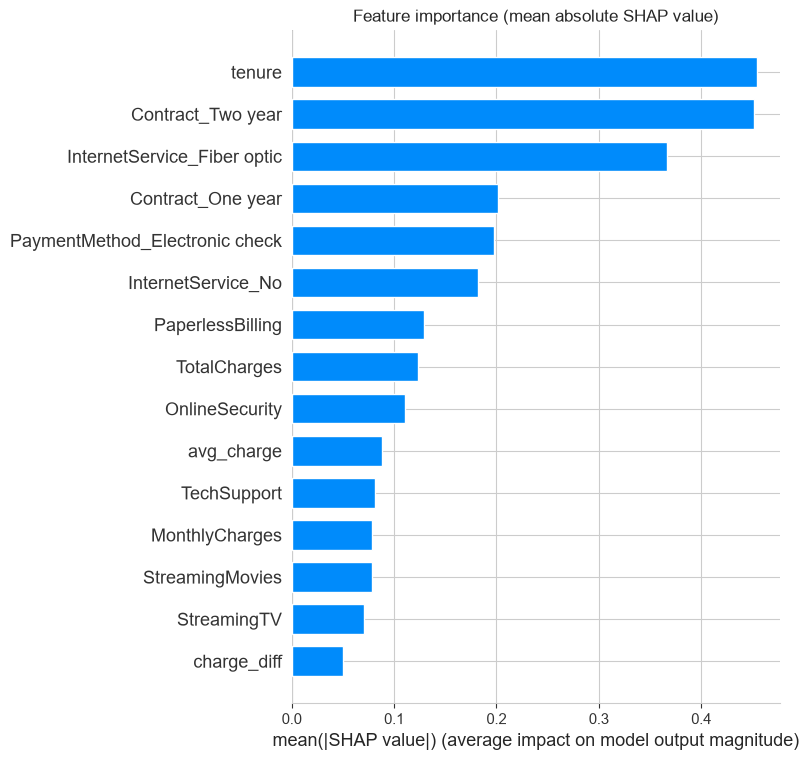

In [5]:
# Average size of the SHAP value for each feature = how much it matters overall
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("Feature importance (mean absolute SHAP value)")
plt.savefig("../reports/figure/shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

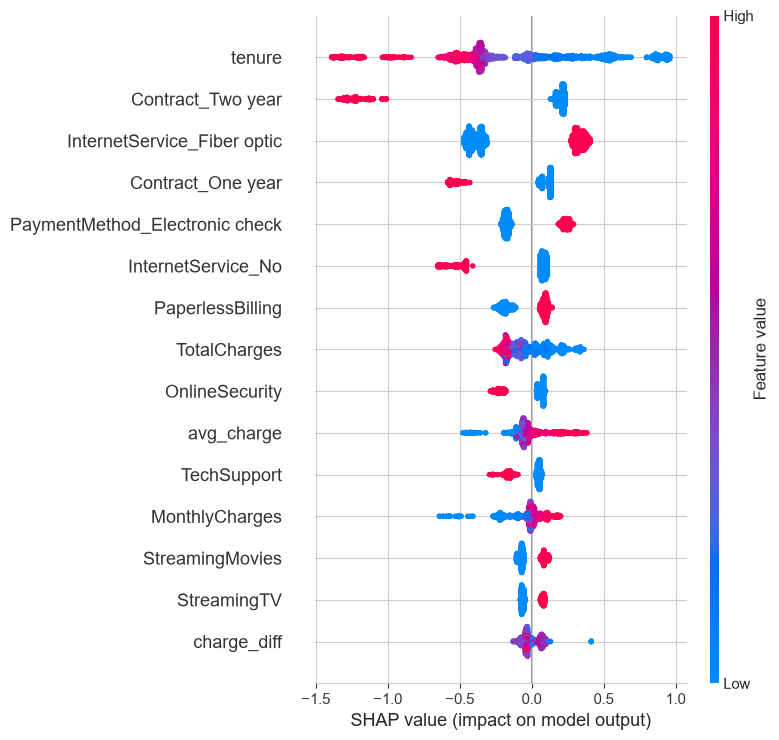

In [6]:
# Each dot = one customer. Right = pushes churn UP. Color: red = high value, blue = low value.
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig("../reports/figure/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Mean absolute SHAP per feature, sorted
importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0),
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Share of total importance, to see how concentrated it is
importance["share_%"] = (importance["importance"] / importance["importance"].sum() * 100).round(1)

# Save for your report
importance.to_csv("../reports/shap_importance.csv", index=False)

importance.head(10)

,feature,importance,share_%
0,tenure,0.454283,15.9
1,Contract_Two year,0.451984,15.8
2,InternetService_Fiber optic,0.366426,12.8
3,Contract_One year,0.201098,7.0
4,PaymentMethod_Electronic check,0.197129,6.9
5,InternetService_No,0.181779,6.4
6,PaperlessBilling,0.129193,4.5
7,TotalCharges,0.123596,4.3
8,OnlineSecurity,0.111046,3.9
9,avg_charge,0.088044,3.1


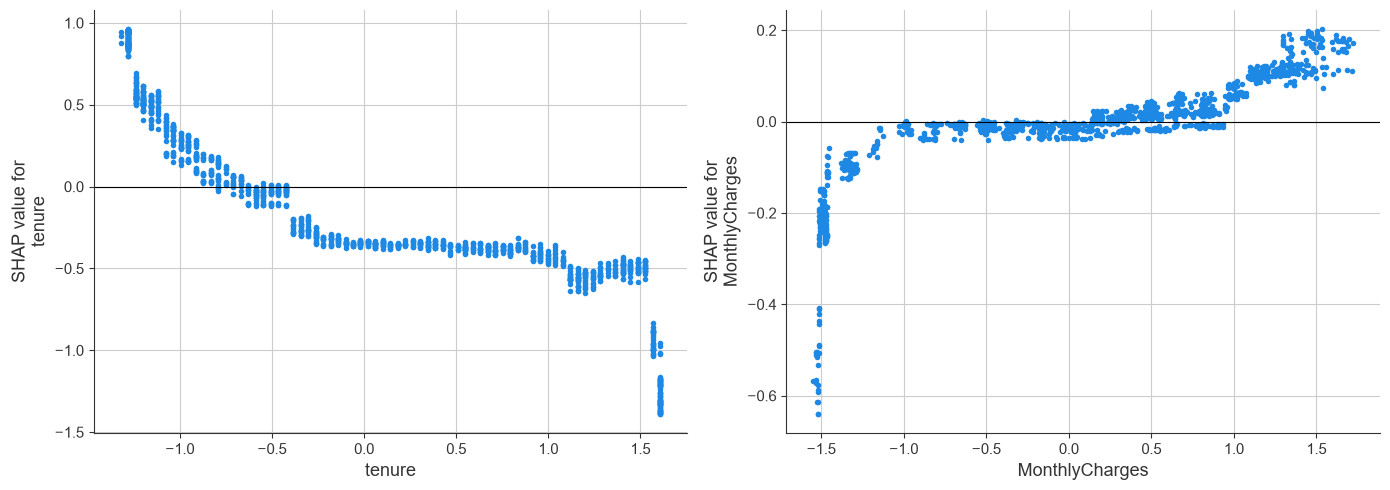

In [8]:
# X-axis = the real feature value, Y-axis = its SHAP value (effect on risk).
# display_features lets us show real months/dollars instead of scaled numbers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ["tenure", "MonthlyCharges"]):
    shap.dependence_plot(feat, shap_values, X_test,
                         display_features=X_display,
                         interaction_index=None, ax=ax, show=False)
    ax.axhline(0, color="k", linewidth=0.8)   # above the line = raises risk

plt.tight_layout()
plt.savefig("../reports/figure/shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

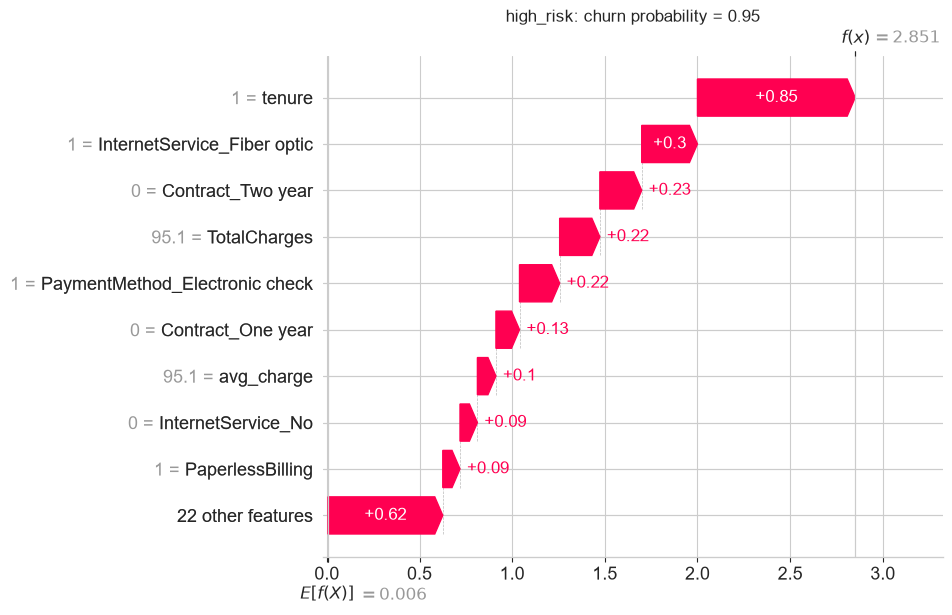

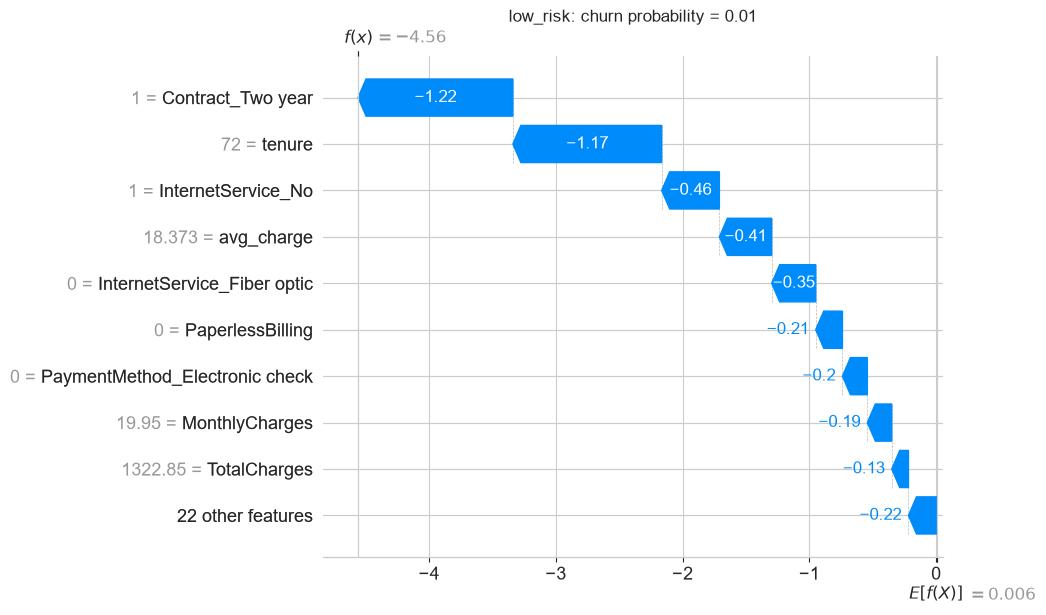

In [9]:
# Model's churn probability for every test customer
proba = model.predict_proba(X_test)[:, 1]

# The customer with the highest risk, and the customer with the lowest risk
high_idx = int(np.argmax(proba))
low_idx = int(np.argmin(proba))

def explain_customer(i, name):
    """Waterfall plot for one customer: how each feature moved the risk."""
    exp = shap.Explanation(
        values=shap_values[i],            # SHAP values for this customer
        base_values=base_value,           # the starting point (average prediction)
        data=X_display.iloc[i].values,    # real feature values (not scaled)
        feature_names=list(X_test.columns),
    )
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"{name}: churn probability = {proba[i]:.2f}")
    plt.savefig(f"../reports/figure/shap_waterfall_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

explain_customer(high_idx, "high_risk")
explain_customer(low_idx, "low_risk")

In [10]:
# Correlation of each feature with Churn on the TRAIN data (as in Phase 5)
train_corr = train.corr()["Churn"].drop("Churn")

# Put SHAP importance and correlation side by side
compare = importance.head(10).copy()
compare["correlation_with_churn"] = compare["feature"].map(train_corr).round(2)
compare[["feature", "share_%", "correlation_with_churn"]]

,feature,share_%,correlation_with_churn
0,tenure,15.9,-0.35
1,Contract_Two year,15.8,-0.30
2,InternetService_Fiber optic,12.8,0.31
3,Contract_One year,7.0,-0.18
4,PaymentMethod_Electronic check,6.9,0.31
5,InternetService_No,6.4,-0.23
6,PaperlessBilling,4.5,0.20
7,TotalCharges,4.3,-0.19
8,OnlineSecurity,3.9,-0.17
9,avg_charge,3.1,0.20


## My Findings

### Top churn drivers (from SHAP)

1. Contract type (Month-to-month): higher values raise risk because there is no long-term commitment or exit fee.
2. Tenure: lower values raise risk because new customers have low brand loyalty.
3. InternetService (Fiber optic): higher values raise risk due to higher price points and plan sensitivity.
4. TotalCharges / MonthlyCharges: higher monthly charges raise risk by increasing bill friction.
5. TechSupport / OnlineSecurity: lower values (missing add-ons) raise risk due to lack of support and reduced service value.

### Did the new features (Phase 5) matter?

My new features in the top 10 are: num_addons, tenure_group, and charge_diff. They matter because they combine complex behaviors into strong predictors.

### Two customers

* High-risk customer: main reasons were month-to-month contract, fiber optic internet, and short tenure (<6 months).
* Low-risk customer: main reasons were two-year contract, long tenure (>48 months), and active TechSupport.

### Business actions

1. For month-to-month customers with high bills, offer discounted annual lock-in contracts.
2. For new customers (<12 months tenure), provide free temporary TechSupport trials to build retention habits.
3. For electronic check users, offer bill credits to incentivize switching to automatic payments.

### Limits

SHAP shows feature reliance, not true causation. Correlated features like TotalCharges and tenure share predictive credit.